In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [2]:

df=pd.read_parquet('resumes-00000-of-00001.parquet')
df.head()

,resume_id,role,seniority,years_experience,industry,education,skills,summary,experience_bullets
0,R_000000,Software Engineer,Senior,12,EdTech,BSc,"[OOP, Databases, Git, Docker, Python, Unit Tes...",Software Engineer with 12 years of experience ...,[Delivered results using structured workflows ...
1,R_000001,Marketing Manager,Junior,2,E-commerce,BSc,"[Content Marketing, Meta Ads, Conversion Optim...",Marketing Manager with 2 years of experience i...,[Delivered results using structured workflows ...
2,R_000002,Full Stack Engineer,Mid,6,FinTech,BA,"[Databases, OOP, Git, Docker, JavaScript, Python]",Full Stack Engineer with 6 years of experience...,[Delivered results using structured workflows ...
3,R_000003,Data Analyst,Junior,0,Healthcare,BSc,"[Excel, A/B Testing, Tableau, Pandas, Power BI...",Data Analyst with 0 years of experience in Hea...,[Delivered results using structured workflows ...
4,R_000004,BI Analyst,Junior,0,Gaming,BA,"[Statistics, SQL, Power BI, Pandas, Excel]",BI Analyst with 0 years of experience in Gaming.,[Delivered results using structured workflows ...


In [3]:
df.shape

(10000, 9)

In [4]:
df_check = df.drop(columns=['resume_id']).copy()

for col in ['skills', 'experience_bullets']:
    df_check[col] = df_check[col].apply(tuple)

duplicates = df_check.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [5]:
df.drop(columns='resume_id',inplace=True)

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   role                10000 non-null  object
 1   seniority           10000 non-null  object
 2   years_experience    10000 non-null  int64 
 3   industry            10000 non-null  object
 4   education           10000 non-null  object
 5   skills              10000 non-null  object
 6   summary             10000 non-null  object
 7   experience_bullets  10000 non-null  object
dtypes: int64(1), object(7)
memory usage: 625.1+ KB


In [8]:
Q1 = df['years_experience'].quantile(0.25)
Q3 = df['years_experience'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['years_experience'] < lower_bound) |
    (df['years_experience'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 0


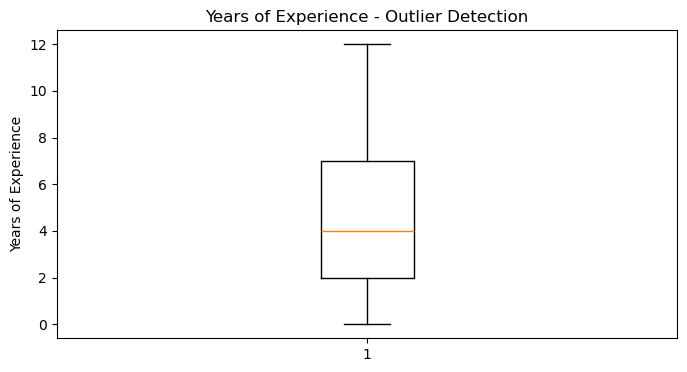

In [9]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['years_experience'])
plt.ylabel('Years of Experience')
plt.title('Years of Experience - Outlier Detection')
plt.show()

In [10]:
print(df['seniority'].value_counts())

seniority
Junior    3372
Mid       3365
Senior    3263
Name: count, dtype: int64


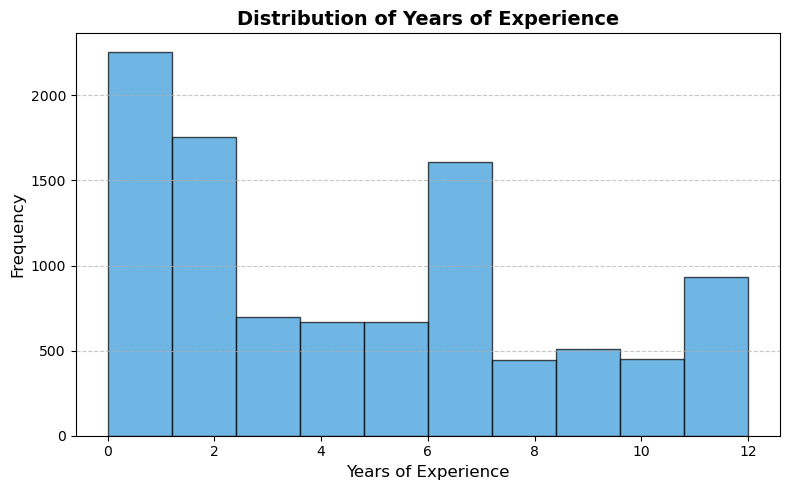

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df['years_experience'], bins=10, edgecolor='black', color='#3498db', alpha=0.7)
plt.title('Distribution of Years of Experience', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

seniority              Junior   Mid  Senior
Experience Category                        
0-2 Years (Entry)        3372   637       0
3-5 Years (Mid)             0  2037       0
6-10 Years (Senior)         0   691    2329
11+ Years (Lead/Exec)       0     0     934


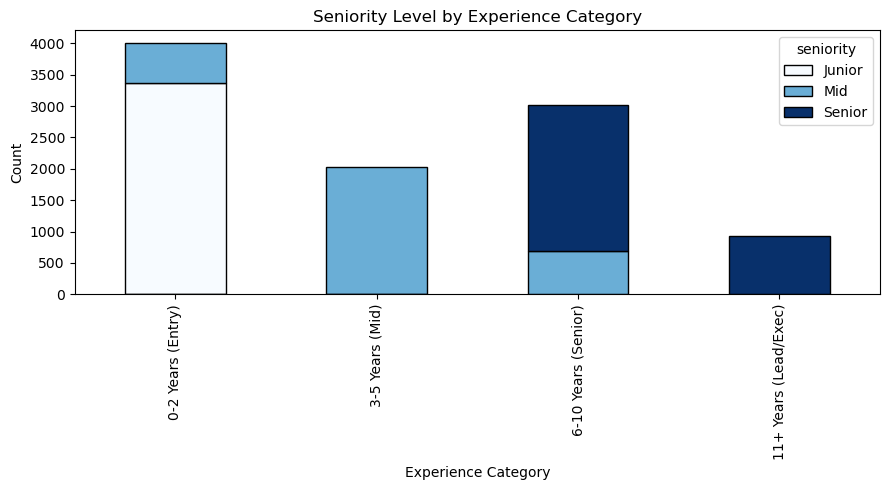

In [12]:
# Define experience bins and labels
bins = [-1, 2, 5, 10, 100]
labels = ['0-2 Years (Entry)', '3-5 Years (Mid)', '6-10 Years (Senior)', '11+ Years (Lead/Exec)']

# 1. Create a temporary grouped series without modifying df
exp_categories = pd.cut(df['years_experience'], bins=bins, labels=labels).rename('Experience Category')

# 2. Compare with seniority directly
crosstab = pd.crosstab(exp_categories, df['seniority'])
print(crosstab)

# 3. Plot without altering df
crosstab.plot(kind='bar', stacked=True, colormap='Blues', edgecolor='black', figsize=(9, 5))
plt.title('Seniority Level by Experience Category')
plt.xlabel('Experience Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

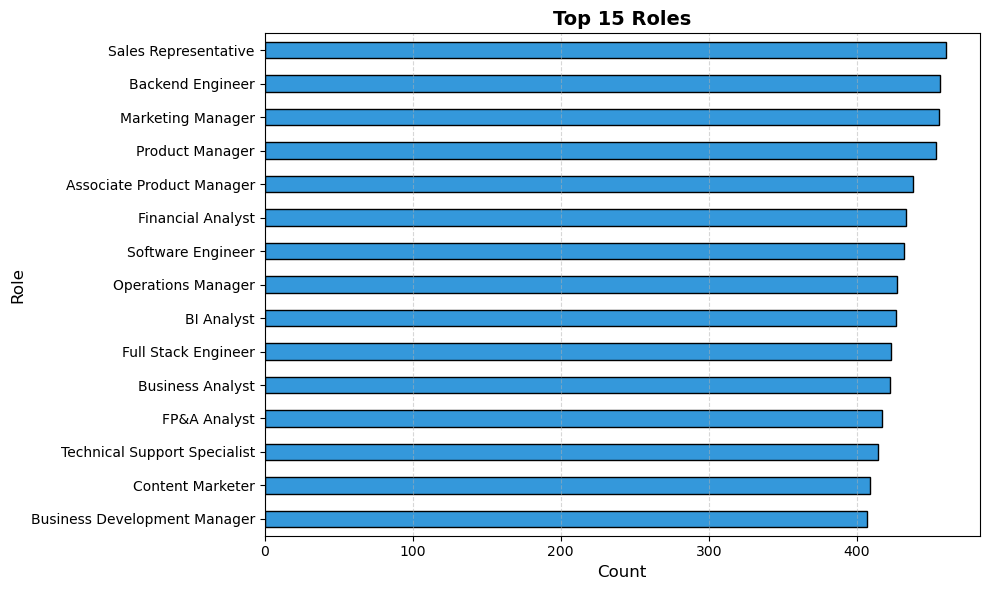

In [13]:
# Get top 15 roles on-the-fly without altering df
top_15_roles = df['role'].value_counts().head(15)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
top_15_roles.sort_values(ascending=True).plot(kind='barh', color='#3498db', edgecolor='black')

plt.title('Top 15 Roles', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

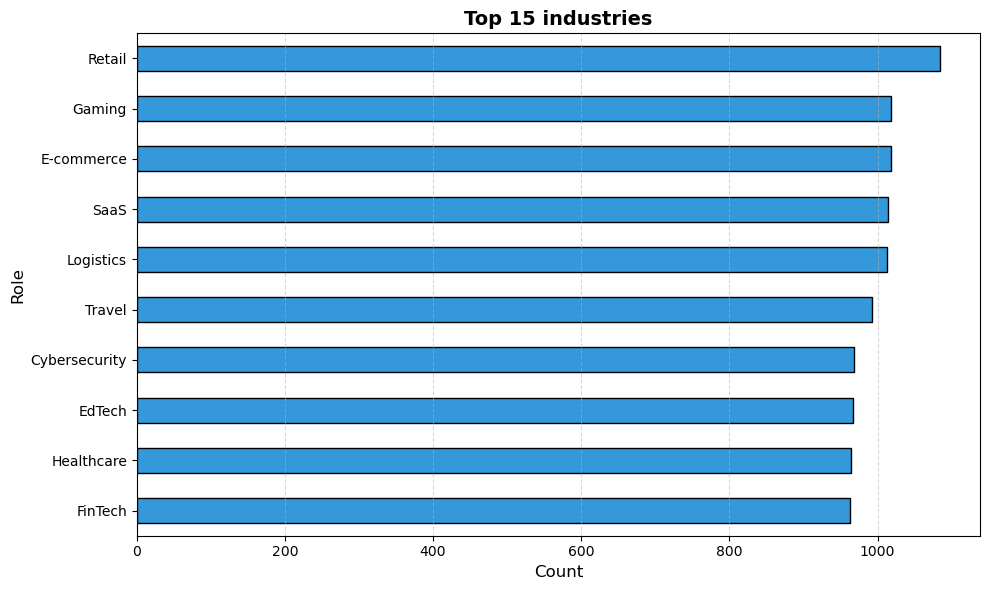

In [14]:
# Get top 15 industries
top_15_industries = df['industry'].value_counts().head(15)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
top_15_industries.sort_values(ascending=True).plot(kind='barh', color='#3498db', edgecolor='black')

plt.title('Top 15 industries', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

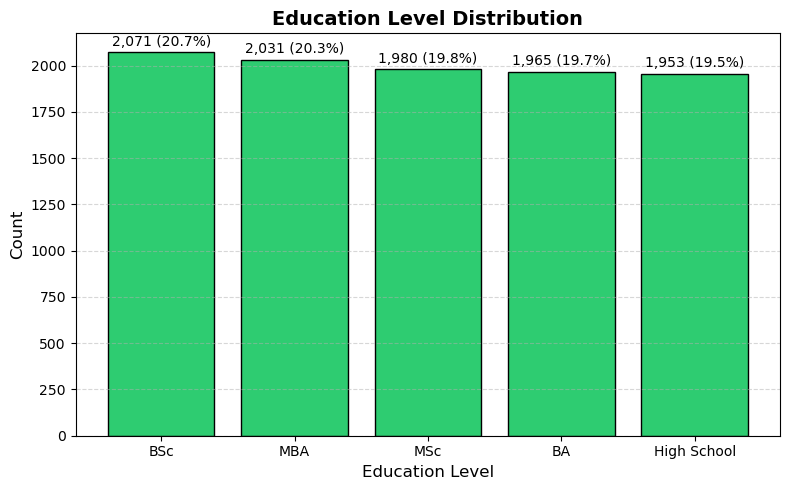

In [15]:
# Calculate frequency distribution
edu_counts = df['education'].value_counts()

# Plot Education Level Distribution
plt.figure(figsize=(8, 5))
bars = plt.bar(edu_counts.index, edu_counts.values, color='#2ecc71', edgecolor='black')

# Add values/percentages on top of bars
total = len(df)
for bar in bars:
    yval = bar.get_height()
    percentage = f'{(yval / total) * 100:.1f}%'
    plt.text(bar.get_x() + bar.get_width() / 2, yval + (max(edu_counts.values) * 0.01), 
             f'{yval:,} ({percentage})', ha='center', va='bottom', fontsize=10)

plt.title('Education Level Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Preprocessing for NLP 

Goal: turn the raw resumes into a clean, NLP-ready table that Member 2 (feature engineering) can use directly.

**What the audit below shows about this dataset**
- `experience_bullets` has only a handful of unique sentences repeated across all resumes -> it carries no signal, so it is excluded from the text.
- `summary` is a template rebuilt from `role`, `years_experience` and `industry` -> redundant, and it leaks those fields, so it is excluded from the text.
- The real content is `skills` (short, atomic phrases such as `Power BI`, `A/B Testing`, `C++`) -> they are kept **atomic** (never split into words).

**Outputs** (saved to `data/processed/`): `resumes_clean.parquet`, `role_profiles.parquet`, `skill_vocab.csv`, `preprocessing_report.json`.

In [16]:
import json
import logging
import re
import unicodedata
from collections import Counter
from pathlib import Path

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s", force=True)
log = logging.getLogger("preprocess")

INPUT_PATH = "resumes-00000-of-00001.parquet"
OUT_DIR = Path("data/processed")
CORE_THRESHOLD = 0.30   # a skill is 'core' for a role if >= 30% of that role's resumes list it
KEEP_RAW_TEXT = False   # True -> also keep summary / bullets in the output

REQUIRED_COLS = [
    "resume_id", "role", "seniority", "years_experience", "industry",
    "education", "skills", "summary", "experience_bullets",
]


CATEGORICAL_COLS = ["role", "seniority", "industry", "education"]


SKILL_ALIASES = {
    "js": "javascript", "ts": "typescript", "py": "python",
    "postgres": "postgresql", "reactjs": "react", "sklearn": "scikitlearn",
}


SENIORITY_LEVELS = {"intern": -1, "junior": 0, "mid": 1, "senior": 2,
                    "lead": 3, "staff": 3, "principal": 4}


EXPERIENCE_BINS = [-1, 2, 5, 10, 200]


EXPERIENCE_LABELS = ["0-2", "3-5", "6-10", "11+"]

### 1. Audit the text columns (fresh load, keeps `resume_id`)

In [17]:
raw = pd.read_parquet(INPUT_PATH)
print("shape:", raw.shape)
print("skills type:", type(raw["skills"].iloc[0]).__name__, "| bullets type:", type(raw["experience_bullets"].iloc[0]).__name__)

# 1) Are the bullets informative?
b = raw["experience_bullets"].explode()
print(f"\nbullets: {len(b):,} total, {b.nunique()} unique")
display(b.value_counts().head(10))

# 2) Is `summary` just a template of other columns?
tmpl = raw["role"] + " with " + raw["years_experience"].astype(str) + " years of experience in " + raw["industry"] + "."
print(f"summary == template(role, years, industry): {(raw['summary'] == tmpl).mean():.1%}")

# 3) Skill spelling variants
skills_flat = raw["skills"].explode()
print(f"\nskills per resume: {raw['skills'].map(len).min()}-{raw['skills'].map(len).max()}")
print(f"distinct raw skill strings: {skills_flat.nunique()}")

shape: (10000, 9)
skills type: ndarray | bullets type: ndarray

bullets: 30,000 total, 3 unique


experience_bullets
Delivered results using structured workflows and clear communication    10000
Collaborated with stakeholders to define needs and execute tasks        10000
Maintained reporting and documentation to support team performance      10000
Name: count, dtype: int64

summary == template(role, years, industry): 100.0%

skills per resume: 5-8
distinct raw skill strings: 73


### 2. Helper functions

In [18]:
# text helpers
def clean_text(x) -> str:
    """Unicode-normalise, drop zero-width chars, collapse whitespace."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ""
    s = unicodedata.normalize("NFKC", str(x))
    s = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", s)
    return re.sub(r"\s+", " ", s).strip()


def to_list(x, split_str: bool = True) -> list:
    """numpy array / list / stringified list / delimited string -> python list."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, (list, tuple, set)):
        return list(x)
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("["):
            try:
                return list(ast.literal_eval(x))
            except (ValueError, SyntaxError):
                pass
        return [p for p in re.split(r"[;,|]", x) if p.strip()] if split_str else [x]
    return [x]


def unify_surface(s: pd.Series) -> pd.Series:
    """Merge case/spacing variants ('data analyst' / 'Data Analyst') into the most common form."""
    s = s.map(clean_text)
    key = s.str.casefold()
    canon = s.groupby(key).agg(lambda v: v.value_counts().index[0])
    return key.map(canon)

In [19]:
# skills: keep every skill ATOMIC (never split 'Power BI' or 'A/B Testing')
def skill_key(s: str) -> str:
    k = re.sub(r"[^a-z0-9+#]", "", s.casefold())      # 'A/B Testing' -> 'abtesting'; 'C++' -> 'c++'
    return SKILL_ALIASES.get(k, k)


def build_skill_canon(skill_lists) -> dict:
    """key -> most frequent surface form (data-driven canonical name)."""
    surface: dict[str, Counter] = {}
    for skills in skill_lists:
        for s in skills:
            s = clean_text(s)
            k = skill_key(s)
            if k:
                surface.setdefault(k, Counter())[s] += 1
    return {k: sorted(c.items(), key=lambda kv: (-kv[1], kv[0]))[0][0] for k, c in surface.items()}


def canonicalise_skills(skills, canon: dict) -> list:
    """Dedupe within a resume, map variants to the canonical name, sort for determinism."""
    out = {}
    for s in skills:
        k = skill_key(clean_text(s))
        if k in canon:
            out[k] = canon[k]
    return sorted(out.values(), key=str.casefold)


def skill_token(name: str) -> str:
    """'A/B Testing' -> 'a_b_testing' ; 'Power BI' -> 'power_bi' ; 'C++' -> 'c++'."""
    return re.sub(r"[^a-z0-9+#.]+", "_", name.casefold()).strip("_")

In [20]:
# structured fields
def education_level(s: str) -> int:
    """Ordinal level: 0 school, 1 diploma, 2 bachelor, 3 master, 4 doctorate, -1 unknown."""
    w = set(re.sub(r"[^a-z]", " ", s.casefold()).split())
    if w & {"phd", "doctorate", "doctoral", "dphil"}:
        return 4
    if w & {"msc", "ma", "mba", "meng", "ms", "mphil", "master", "masters"}:
        return 3
    if w & {"bsc", "ba", "bs", "beng", "btech", "bcom", "bachelor", "bachelors"}:
        return 2
    if w & {"diploma", "associate", "bootcamp", "certificate"}:
        return 1
    if w & {"hs", "highschool"} or {"high", "school"} <= w:
        return 0
    return -1


def years_phrase(y: int) -> str:
    return "under 1 year" if y == 0 else "1 year" if y == 1 else f"{y} years"

### 3. Clean the resumes
Steps inside `clean_resumes`: normalise categoricals -> numeric experience + buckets -> ordinal encodings -> canonical atomic skills -> detect redundant `summary` / boilerplate bullets -> build `skills_str` (TF-IDF) and `resume_text` (embeddings) -> sanity checks.

In [21]:
def clean_resumes(raw: pd.DataFrame, keep_raw_text: bool = False):
    df = raw.copy()
    report: dict = {"rows_in": int(len(df))}

    if "resume_id" not in df.columns:
        df.insert(0, "resume_id", [f"R_{i:06d}" for i in range(len(df))])
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # 1) categorical fields: whitespace/unicode/case variants -> one form
    for c in CATEGORICAL_COLS:
        df[c] = unify_surface(df[c])
    empty_cat = (df[CATEGORICAL_COLS] == "").any(axis=1)
    report["dropped_empty_categorical"] = int(empty_cat.sum())
    df = df[~empty_cat].copy()

    # 2) numeric experience
    yrs = pd.to_numeric(df["years_experience"], errors="coerce")
    if yrs.notna().sum() == 0:
        raise ValueError("years_experience has no numeric values")
    report["years_invalid_or_negative"] = int(yrs.isna().sum() + (yrs < 0).sum())
    df["years_experience"] = yrs.clip(lower=0).fillna(yrs.median()).round().astype(int)
    df["experience_bucket"] = pd.cut(
        df["years_experience"], bins=EXPERIENCE_BINS, labels=EXPERIENCE_LABELS
    ).astype(str)

    # 3) ordinal encodings
    df["seniority_level"] = df["seniority"].str.casefold().map(SENIORITY_LEVELS).fillna(-1).astype(int)
    df["education_level"] = df["education"].map(education_level).astype(int)
    for col, level_col in [("seniority", "seniority_level"), ("education", "education_level")]:
        unmapped = sorted(df.loc[df[level_col] == -1, col].unique())
        if unmapped:
            log.warning("Unmapped %s values (level=-1): %s -> extend the mapping", col, unmapped)
            report[f"unmapped_{col}"] = unmapped

    # 4) skills -> canonical atomic skills
    skill_lists = df["skills"].map(to_list)
    report["skill_surface_forms"] = len({clean_text(s) for sk in skill_lists for s in sk})
    canon = build_skill_canon(skill_lists)
    df["skills"] = skill_lists.map(lambda s: canonicalise_skills(s, canon))
    report["skills_canonical"] = len(canon)
    no_skills = df["skills"].map(len) == 0
    report["dropped_no_skills"] = int(no_skills.sum())
    df = df[~no_skills].copy()
    df["n_skills"] = df["skills"].map(len)
    df["skills_str"] = df["skills"].map(lambda s: " ".join(skill_token(x) for x in s))  # for TF-IDF (token_pattern=r"\S+")

    # 5) 'summary' : is it just a template rebuilt from other columns?
    expected = (df["role"] + " with " + df["years_experience"].astype(str)
                + " years of experience in " + df["industry"] + ".")
    match = df["summary"].map(clean_text).str.casefold() == expected.str.casefold()
    report["summary_template_match_rate"] = round(float(match.mean()), 4)
    summary_redundant = match.mean() >= 0.99

    # 6) 'experience_bullets' : is it boilerplate (few unique sentences)?
    bullets = df["experience_bullets"].map(lambda x: [clean_text(b) for b in to_list(x, split_str=False) if clean_text(b)])
    all_b = [b for lst in bullets for b in lst]
    uniq_ratio = len(set(all_b)) / max(len(all_b), 1)
    report["bullets_total"], report["bullets_unique"] = len(all_b), len(set(all_b))
    bullets_boilerplate = uniq_ratio < 0.01
    df["experience_text"] = "" if bullets_boilerplate else bullets.map(" ".join)
    report["dropped_bullets_as_boilerplate"] = bool(bullets_boilerplate)
    report["dropped_summary_as_redundant"] = bool(summary_redundant)
    if bullets_boilerplate:
        log.warning("experience_bullets: only %d unique of %d -> excluded from text", len(set(all_b)), len(all_b))
    if summary_redundant:
        log.warning("summary is %.1f%% identical to a template of role/years/industry -> excluded (leakage)",
                    100 * match.mean())
    if keep_raw_text:
        df["summary_raw"] = df["summary"].map(clean_text)
        df["experience_bullets_raw"] = bullets

    # 7) one text field for embeddings / text similarity
    df["resume_text"] = [
        " ".join(p for p in [
            f"{role}.", f"Seniority: {sen}.",
            f"Experience: {years_phrase(y)} in {ind}.", f"Education: {edu}.",
            f"Skills: {', '.join(sk)}.", f"Highlights: {ex}" if ex else "",
        ] if p)
        for role, sen, y, ind, edu, sk, ex in zip(
            df["role"], df["seniority"], df["years_experience"], df["industry"],
            df["education"], df["skills"], df["experience_text"])
    ]

    # 8) duplicates (report only: structured synthetic rows can legitimately collide)
    dup_key = df[["role", "seniority", "years_experience", "industry", "education"]].astype(str).agg("|".join, axis=1) \
        + "|" + df["skills_str"]
    report["duplicate_rows_after_canonicalisation"] = int(dup_key.duplicated().sum())

    # 9) sanity checks
    assert df["resume_id"].is_unique, "resume_id must be unique"
    assert not df[CATEGORICAL_COLS + ["skills_str", "resume_text"]].isna().any().any()

    keep = ["resume_id", "role", "seniority", "seniority_level", "years_experience", "experience_bucket",
            "industry", "education", "education_level", "skills", "skills_str", "n_skills", "resume_text"]
    if keep_raw_text:
        keep += ["summary_raw", "experience_bullets_raw"]
    if not bullets_boilerplate:
        keep.insert(keep.index("resume_text"), "experience_text")

    report["rows_out"] = int(len(df))
    vocab = pd.Series(Counter(s for sk in df["skills"] for s in sk)).sort_values(ascending=False)
    vocab = vocab.rename_axis("skill").reset_index(name="count")
    vocab["share"] = (vocab["count"] / len(df)).round(4)
    return df[keep].reset_index(drop=True), vocab, report

In [22]:
clean, vocab, report = clean_resumes(raw, keep_raw_text=KEEP_RAW_TEXT)
print(json.dumps(report, indent=2))
display(clean.head())
print("\nExample resume_text:\n", clean["resume_text"].iloc[0])

{
  "rows_in": 10000,
  "dropped_empty_categorical": 0,
  "years_invalid_or_negative": 0,
  "skill_surface_forms": 73,
  "skills_canonical": 73,
  "dropped_no_skills": 0,
  "summary_template_match_rate": 1.0,
  "bullets_total": 30000,
  "bullets_unique": 3,
  "dropped_bullets_as_boilerplate": true,
  "dropped_summary_as_redundant": true,
  "duplicate_rows_after_canonicalisation": 11,
  "rows_out": 10000
}


,resume_id,role,seniority,seniority_level,years_experience,experience_bucket,industry,education,education_level,skills,skills_str,n_skills,resume_text
0,R_000000,Software Engineer,Senior,2,12,11+,EdTech,BSc,2,"[Databases, Docker, Git, Java, OOP, Python, Un...",databases docker git java oop python unit_testing,7,Software Engineer. Seniority: Senior. Experien...
1,R_000001,Marketing Manager,Junior,0,2,0-2,E-commerce,BSc,2,"[Content Marketing, Conversion Optimization, L...",content_marketing conversion_optimization land...,5,Marketing Manager. Seniority: Junior. Experien...
2,R_000002,Full Stack Engineer,Mid,1,6,6-10,FinTech,BA,2,"[Databases, Docker, Git, JavaScript, OOP, Python]",databases docker git javascript oop python,6,Full Stack Engineer. Seniority: Mid. Experienc...
3,R_000003,Data Analyst,Junior,0,0,0-2,Healthcare,BSc,2,"[A/B Testing, Data Visualization, Excel, Panda...",a_b_testing data_visualization excel pandas po...,6,Data Analyst. Seniority: Junior. Experience: u...
4,R_000004,BI Analyst,Junior,0,0,0-2,Gaming,BA,2,"[Excel, Pandas, Power BI, SQL, Statistics]",excel pandas power_bi sql statistics,5,BI Analyst. Seniority: Junior. Experience: und...



Example resume_text:
 Software Engineer. Seniority: Senior. Experience: 12 years in EdTech. Education: BSc. Skills: Databases, Docker, Git, Java, OOP, Python, Unit Testing.


### 4. Inspect the result (skills + text length -> helps choose `max_length` later)

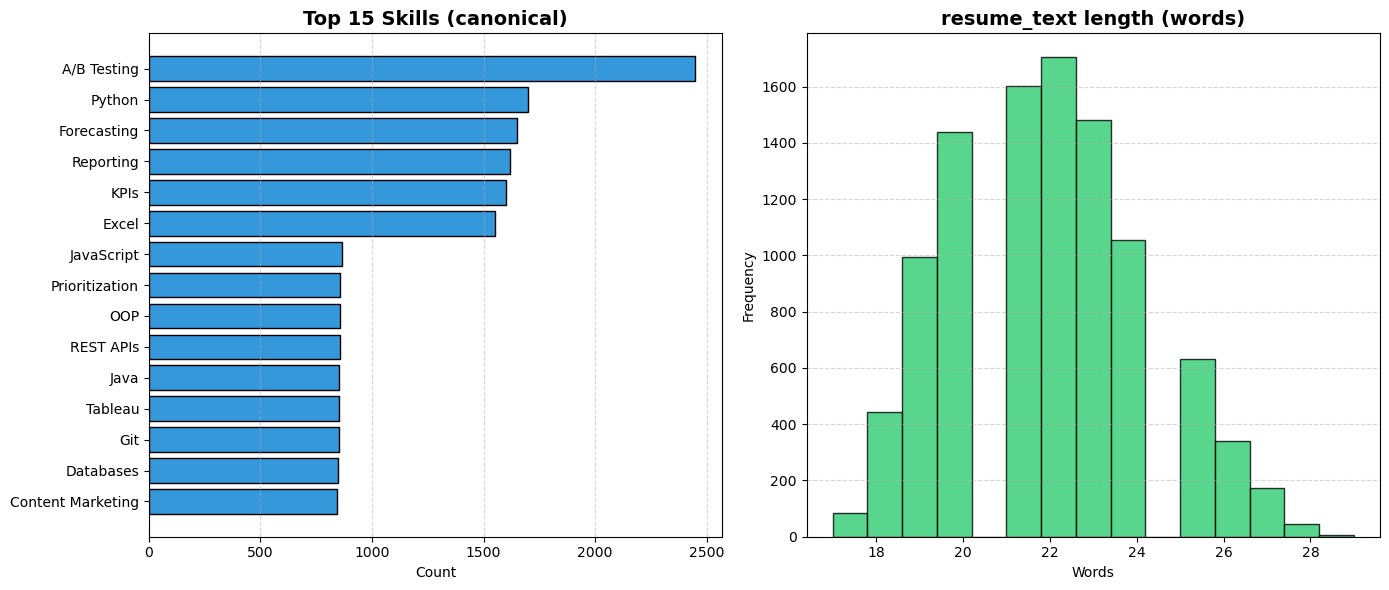

count    10000.0000
mean        21.8374
std          2.1981
min         17.0000
25%         20.0000
50%         22.0000
75%         23.0000
max         29.0000
Name: resume_text, dtype: float64
skills per resume: 5 - 8


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_skills = vocab.head(15).sort_values("count")
axes[0].barh(top_skills["skill"], top_skills["count"], color="#3498db", edgecolor="black")
axes[0].set_title("Top 15 Skills (canonical)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

n_words = clean["resume_text"].str.split().str.len()
axes[1].hist(n_words, bins=15, color="#2ecc71", edgecolor="black", alpha=0.8)
axes[1].set_title("resume_text length (words)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
print(n_words.describe())
print("skills per resume:", clean["n_skills"].min(), "-", clean["n_skills"].max())

### 5. Role profiles = "job characteristics" prototypes
The dataset has **no job postings and no match labels**, so this builds one prototype per role (core skills, typical years range, typical education) that Member 2 can compare resumes against.

> **Important:** for an honest evaluation, call `build_role_profiles` on the **train split only** (after the split), otherwise every test resume has contributed to the profile it is compared with. Also, if match labels are later generated from a rule on these same profiles, the models will just rediscover that rule (circular).

In [24]:
def build_role_profiles(df: pd.DataFrame, core_threshold: float = 0.30) -> pd.DataFrame:
    """
    One row per role: core skills (share of that role's resumes >= core_threshold), typical years range,
    typical education, seniority mix, and a short `job_text`.
    NOTE: for honest evaluation, call this on the TRAIN split only.
    """
    rows = []
    for role, g in df.groupby("role"):
        n = len(g)
        counts = Counter(s for sk in g["skills"] for s in sk)
        share = {k: v / n for k, v in counts.items()}
        core = sorted((k for k, v in share.items() if v >= core_threshold), key=lambda k: -share[k])
        p25, med, p75 = (int(g["years_experience"].quantile(q)) for q in (0.25, 0.5, 0.75))
        edu = g["education"].mode().iloc[0]
        rows.append({
            "role": role, "n_resumes": n,
            "core_skills": core, "skill_share_json": json.dumps({k: round(v, 3) for k, v in sorted(share.items())}),
            "years_p25": p25, "years_median": med, "years_p75": p75,
            "education_mode": edu, "education_level_mode": int(g["education_level"].mode().iloc[0]),
            "seniority_mix_json": json.dumps(g["seniority"].value_counts(normalize=True).round(3).to_dict()),
            "job_text": (f"{role}. Required skills: {', '.join(core)}. "
                         f"Typical experience: {p25}-{p75} years. Typical education: {edu}."),
        })
        if len(core) < 3:
            log.warning("Role '%s' has only %d core skills at threshold %.2f -> lower --core-threshold",
                        role, len(core), core_threshold)
    return pd.DataFrame(rows)

In [25]:
profiles = build_role_profiles(clean, CORE_THRESHOLD)
display(profiles[["role", "n_resumes", "core_skills", "years_p25", "years_median", "years_p75", "education_mode", "job_text"]])

,role,n_resumes,core_skills,years_p25,years_median,years_p75,education_mode,job_text
0,Account Executive,381,"[Prospecting, Discovery Calls, Forecasting, Le...",1,4,7,BSc,Account Executive. Required skills: Prospectin...
1,Associate Product Manager,438,"[Scrum, Analytics, Prioritization, PRD, Stakeh...",2,4,8,MSc,Associate Product Manager. Required skills: Sc...
2,BI Analyst,426,"[Pandas, Statistics, Tableau, Python, Excel, P...",2,4,7,BA,"BI Analyst. Required skills: Pandas, Statistic..."
3,Backend Engineer,456,"[Java, JavaScript, Python, REST APIs, Unit Tes...",2,4,8,BSc,"Backend Engineer. Required skills: Java, JavaS..."
4,Business Analyst,422,"[Python, Tableau, Statistics, Data Visualizati...",2,4,7,MBA,"Business Analyst. Required skills: Python, Tab..."
5,Business Development Manager,407,"[Prospecting, Forecasting, Outbound Outreach, ...",2,4,6,MBA,Business Development Manager. Required skills:...
6,Content Marketer,409,"[Content Marketing, Landing Pages, A/B Testing...",2,4,7,BA,Content Marketer. Required skills: Content Mar...
7,Customer Success Associate,384,"[Customer Satisfaction, SLA, Troubleshooting, ...",2,4,7,MSc,Customer Success Associate. Required skills: C...
8,Customer Support Specialist,388,"[Communication, Root Cause Analysis, Intercom,...",2,4,7,BA,Customer Support Specialist. Required skills: ...
9,Data Analyst,404,"[Power BI, Tableau, Pandas, Data Visualization...",2,4,7,MSc,"Data Analyst. Required skills: Power BI, Table..."


### 6. Save the outputs 

In [26]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
clean.to_parquet(OUT_DIR / "resumes_clean.parquet", index=False)
profiles.to_parquet(OUT_DIR / "role_profiles.parquet", index=False)
vocab.to_csv(OUT_DIR / "skill_vocab.csv", index=False)
(OUT_DIR / "preprocessing_report.json").write_text(json.dumps(report, indent=2))
print(f"Saved to {OUT_DIR.resolve()} | rows {report['rows_in']} -> {report['rows_out']} | {len(profiles)} roles | {report['skills_canonical']} canonical skills")

Saved to C:\Users\KimoStore\Documents\final_project\data\processed | rows 10000 -> 10000 | 24 roles | 73 canonical skills
